In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
df = pd.read_csv('/content/drive/MyDrive/used_car_sales.csv')

In [48]:
df.head()

,ID,pricesold,yearsold,zipcode,Mileage,Make,Model,Year,Trim,Engine,BodyType,NumCylinders,DriveType
0,137178,7500,2020,786**,84430,Ford,Mustang,1988,LX,5.0L Gas V8,Sedan,0,RWD
1,96705,15000,2019,81006,0,Replica/Kit Makes,Jaguar Beck Lister,1958,NaN,383 Fuel injected,Convertible,8,RWD
2,119660,8750,2020,33449,55000,Jaguar,XJS,1995,2+2 Cabriolet,4.0L In-Line 6 Cylinder,Convertible,6,RWD
3,80773,11600,2019,7852,97200,Ford,Mustang,1968,Stock,289 cu. in. V8,Coupe,8,RWD
4,64287,44000,2019,7728,40703,Porsche,911,2002,Turbo X-50,3.6L,Coupe,6,AWD


In [49]:
df.tail()

,ID,pricesold,yearsold,zipcode,Mileage,Make,Model,Year,Trim,Engine,BodyType,NumCylinders,DriveType
244,39367,7100,2019,85339,1,Chevrolet,Impala,1964,"Super Sport, SS",NaN,NaN,8,NaN
245,8351,4500,2019,85339,1,Dodge,Charger,1966,NaN,361,NaN,8,NaN
246,106689,2740,2020,92649,390000,Dodge,Sprinter,2006,SUPER HIGH CEILING 158WB,2.7L,CARGO VAN,5,RWD
247,38120,28500,2019,50249,28000,Mercedes-Benz,Sprinter,2013,"Wheel Chair Lift in Rear Handicap 26,000 Miles",3.0L,Extended Passenger Van,6,RWD
248,103380,1730,2019,51028,50432,Chrysler,Cordoba,1979,NaN,NaN,NaN,0,NaN


In [50]:
s = df.shape
print(f'Number of rows in the dataset is: {s[0]}\nNumber of columns in the dataset : {s[1]}')

Number of rows in the dataset is: 249
Number of columns in the dataset : 13


In [51]:
dup_val = df['yearsold'].duplicated().sum()
print(f'number of duplicate values in the yearsold column is: {dup_val}')

number of duplicate values in the yearsold column is: 246


In [52]:
dup_count = df['Model'].duplicated().sum()
print(f'Number of duplicate values in Model is {dup_count}')

Number of duplicate values in Model is 114


In [53]:
df.columns

Index(['ID', 'pricesold', 'yearsold', 'zipcode', 'Mileage', 'Make', 'Model',
       'Year', 'Trim', 'Engine', 'BodyType', 'NumCylinders', 'DriveType'],
      dtype='object')

In [54]:
df.describe()

,ID,pricesold,yearsold,Mileage,Year,NumCylinders
count,249.000000,249.000000,249.000000,2.490000e+02,249.000000,249.000000
mean,89472.526104,10836.706827,2019.413655,1.074991e+05,1986.807229,5.473896
std,46953.768795,15680.770469,0.509560,1.536511e+05,20.375185,3.077022
min,801.000000,450.000000,2018.000000,0.000000e+00,1929.000000,0.000000
25%,55855.000000,3150.000000,2019.000000,3.175000e+04,1971.000000,4.000000
50%,90857.000000,6200.000000,2019.000000,8.197600e+04,1990.000000,6.000000
75%,131274.000000,14000.000000,2020.000000,1.250000e+05,2004.000000,8.000000
max,165573.000000,185000.000000,2020.000000,1.234567e+06,2018.000000,8.000000


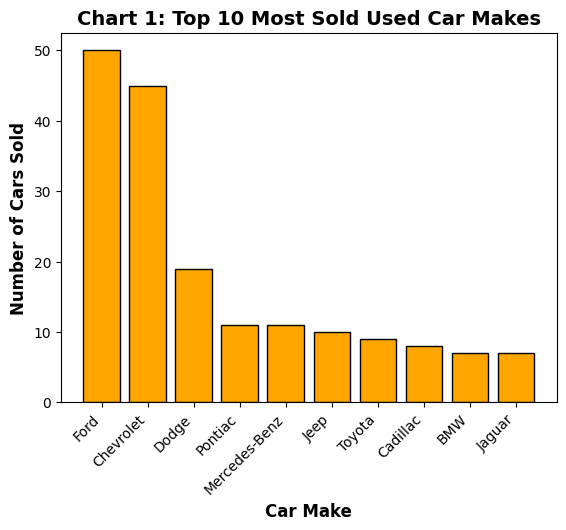

In [55]:
top_makes = df['Make'].value_counts().head(10)
bars = plt.bar(range(len(top_makes)), top_makes.values, color='orange', edgecolor='black')
plt.xlabel('Car Make', fontsize=12, fontweight='bold')
plt.ylabel('Number of Cars Sold', fontsize=12, fontweight='bold')
plt.title('Chart 1: Top 10 Most Sold Used Car Makes', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_makes)), top_makes.index, rotation=45, ha='right')
plt.show()

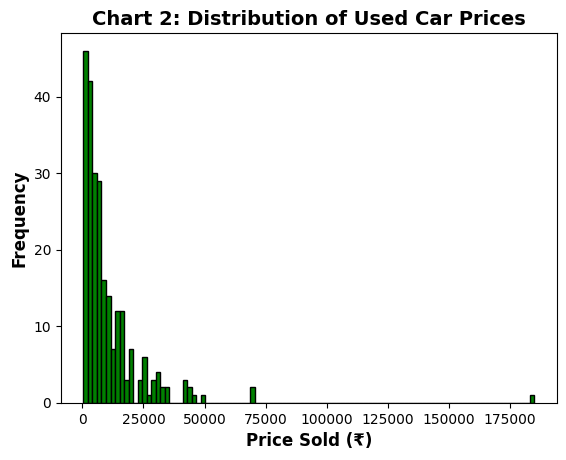

In [56]:
plt.hist(df['pricesold'], bins=100, color='green', edgecolor='black')
plt.xlabel('Price Sold (₹)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Chart 2: Distribution of Used Car Prices', fontsize=14, fontweight='bold')
plt.show()

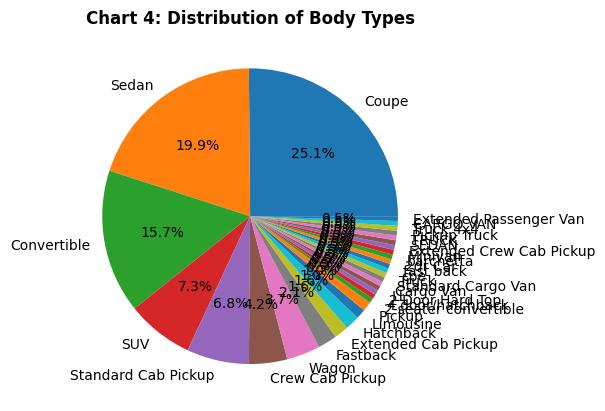

In [59]:
a = df['BodyType'].value_counts()
plt.pie(a.values, labels= a.index, autopct='%1.1f%%')
plt.title('Chart 4: Distribution of Body Types', fontsize=12, fontweight='bold')
plt.show()

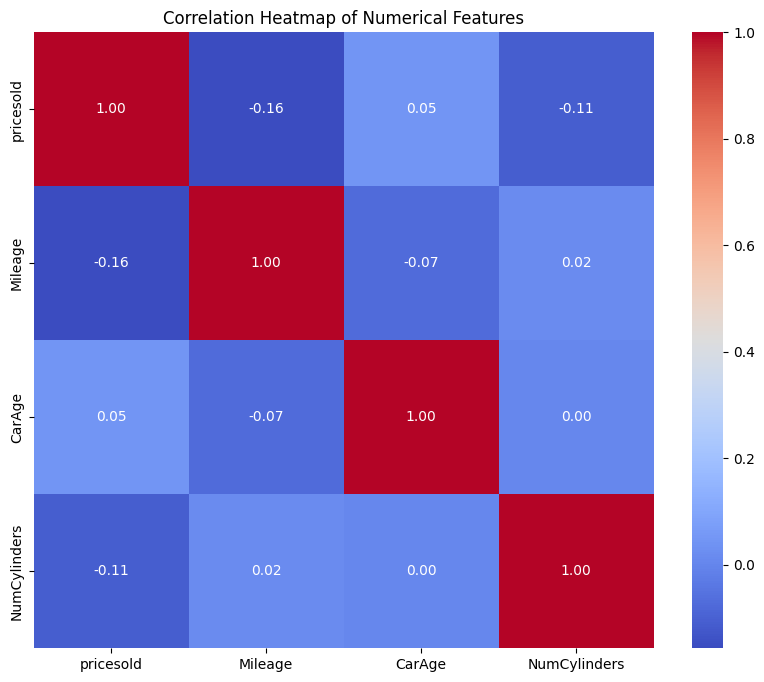

In [58]:
df_clean = df.copy()
df_clean = df_clean[(df_clean['Year'] >= 1900) & (df_clean['Year'] <= df_clean['yearsold'])]
df_clean = df_clean[df_clean['Mileage'] <= 1000000]
df_clean['CarAge'] = df_clean['yearsold'] - df_clean['Year']
num_col = ['pricesold', 'Mileage', 'CarAge', 'NumCylinders']
correlation_matrix = df_clean[num_col].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()